In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print('✅ All imports successful')

✅ All imports successful


In [3]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\mangrove_2020_2025_final.csv")
gee = pd.read_csv(r"C:\Users\DELL\Downloads\gee_export.csv")
gee = gee.drop(columns=['system:index', '.geo'], errors='ignore')

display(df)
display(gee)

,year,mangrove_area_sq_km,reduction_sq_km,reduction_percent
0,2020,24.6026,0.0000,0.0000
1,2021,20.7130,3.8896,15.8096
2,2022,21.6975,2.9051,11.8082
3,2023,21.7592,2.8434,11.5573
4,2024,22.5633,2.0393,8.2889
5,2025,22.6693,1.9333,7.8581


,mangrove_area_sq_km,reduction_percent,reduction_sq_km,year
0,24.602570,0.000000,0.000000,2020
1,20.712999,15.809613,3.889571,2021
2,21.697455,11.808178,2.905115,2022
3,21.759183,11.557276,2.843387,2023
4,22.563286,8.288904,2.039283,2024
5,22.669271,7.858118,1.933299,2025


In [4]:

df = df.sort_values('year').reset_index(drop=True)

# Area in hectares
df['area_ha'] = df['mangrove_area_sq_km'] * 100

# Carbon stock: mangroves store ~150 tC/ha (IPCC Blue Carbon standard)
df['carbon_stock_tc'] = df['area_ha'] * 150

# Carbon lost compared to 2020 baseline
baseline_carbon = df.loc[df['year'] == 2020, 'carbon_stock_tc'].values[0]
df['carbon_loss_tc'] = baseline_carbon - df['carbon_stock_tc']
df['carbon_loss_percent'] = (df['carbon_loss_tc'] / baseline_carbon) * 100

# Simulated urban development index (proxy: inverse of mangrove area, scaled 0–100)
# Represents urban encroachment pressure
max_area = df['mangrove_area_sq_km'].max()
df['urban_index'] = ((max_area - df['mangrove_area_sq_km']) / max_area * 100).round(2)

# Area lost vs 2020 baseline (cumulative)
baseline_area = df.loc[df['year'] == 2020, 'mangrove_area_sq_km'].values[0]
df['area_loss_vs_baseline'] = baseline_area - df['mangrove_area_sq_km']

# CO₂ equivalent: 1 tC = 3.67 tCO₂
df['carbon_stock_co2eq'] = df['carbon_stock_tc'] * 3.67
df['carbon_loss_co2eq'] = df['carbon_loss_tc'] * 3.67

display(df)

,year,mangrove_area_sq_km,reduction_sq_km,reduction_percent,area_ha,carbon_stock_tc,carbon_loss_tc,carbon_loss_percent,urban_index,area_loss_vs_baseline,carbon_stock_co2eq,carbon_loss_co2eq
0,2020,24.6026,0.0000,0.0000,2460.26,369039.0,0.0,0.000000,0.00,0.0000,1354373.130,0.000
1,2021,20.7130,3.8896,15.8096,2071.30,310695.0,58344.0,15.809711,15.81,3.8896,1140250.650,214122.480
2,2022,21.6975,2.9051,11.8082,2169.75,325462.5,43576.5,11.808102,11.81,2.9051,1194447.375,159925.755
3,2023,21.7592,2.8434,11.5573,2175.92,326388.0,42651.0,11.557315,11.56,2.8434,1197843.960,156529.170
4,2024,22.5633,2.0393,8.2889,2256.33,338449.5,30589.5,8.288961,8.29,2.0393,1242109.665,112263.465
5,2025,22.6693,1.9333,7.8581,2266.93,340039.5,28999.5,7.858113,7.86,1.9333,1247944.965,106428.165


In [5]:
from sklearn.linear_model import LinearRegression

X = df[['year']]
y_area = df['mangrove_area_sq_km']
y_carbon = df['carbon_stock_tc']

model_area = LinearRegression().fit(X, y_area)
model_carbon = LinearRegression().fit(X, y_carbon)

future_years = np.arange(2026, 2031).reshape(-1, 1)
pred_area = model_area.predict(future_years)
pred_carbon = model_carbon.predict(future_years)

future_df = pd.DataFrame({
    'year': future_years.flatten(),
    'mangrove_area_sq_km': pred_area,
    'carbon_stock_tc': pred_carbon,
    'type': 'Predicted'
})

print('✅ Predictions ready')
display(future_df)

# Save for streamlit
df.to_csv('mangrove_engineered.csv', index=False)
future_df.to_csv('mangrove_predictions.csv', index=False)
print('\n✅ Exported: mangrove_engineered.csv, mangrove_predictions.csv')

✅ Predictions ready


,year,mangrove_area_sq_km,carbon_stock_tc,type
0,2026,21.928760,328931.400000,Predicted
1,2027,21.812934,327194.014286,Predicted
2,2028,21.697109,325456.628571,Predicted
3,2029,21.581283,323719.242857,Predicted
4,2030,21.465457,321981.857143,Predicted



✅ Exported: mangrove_engineered.csv, mangrove_predictions.csv


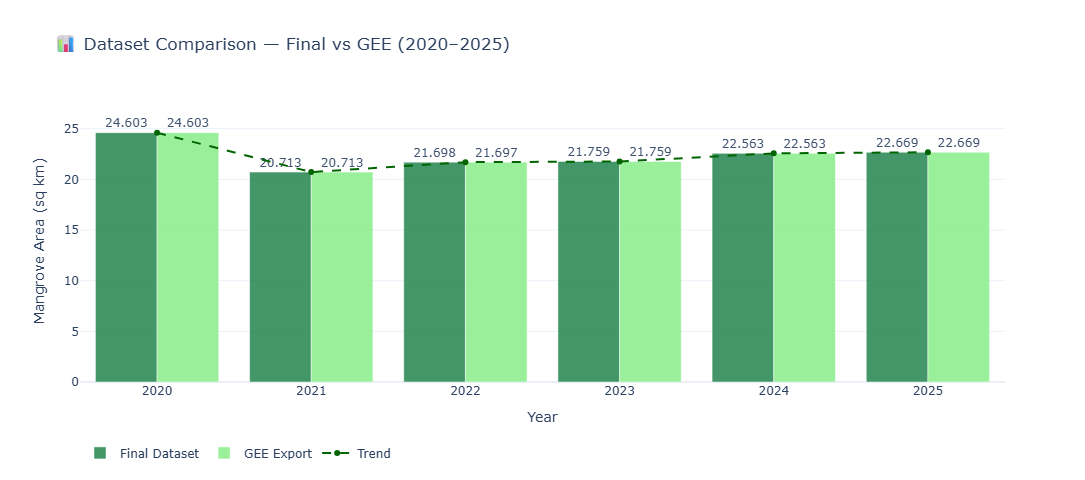

In [6]:
gee_compare = gee.copy()
compare = df.merge(gee_compare[['year','mangrove_area_sq_km']], on='year', how='left', suffixes=('_Final','_GEE'))

fig = go.Figure()

fig.add_trace(go.Bar(
    x=compare['year'], y=compare['mangrove_area_sq_km_Final'],
    name='Final Dataset', marker_color='#2E8B57', opacity=0.9,
    text=[f"{v:.3f}" for v in compare['mangrove_area_sq_km_Final']],
    textposition='outside'
))

fig.add_trace(go.Bar(
    x=compare['year'], y=compare['mangrove_area_sq_km_GEE'],
    name='GEE Export', marker_color='#90EE90', opacity=0.9,
    text=[f"{v:.3f}" for v in compare['mangrove_area_sq_km_GEE']],
    textposition='outside'
))

fig.add_trace(go.Scatter(
    x=compare['year'], y=compare['mangrove_area_sq_km_Final'],
    mode='lines+markers', name='Trend',
    line=dict(color='#006400', width=2, dash='dash')
))

fig.update_layout(
    title='📊 Dataset Comparison — Final vs GEE (2020–2025)',
    xaxis_title='Year', yaxis_title='Mangrove Area (sq km)',
    barmode='group', template='plotly_white', height=480,
    legend=dict(orientation='h', y=-0.2)
)

fig.show()

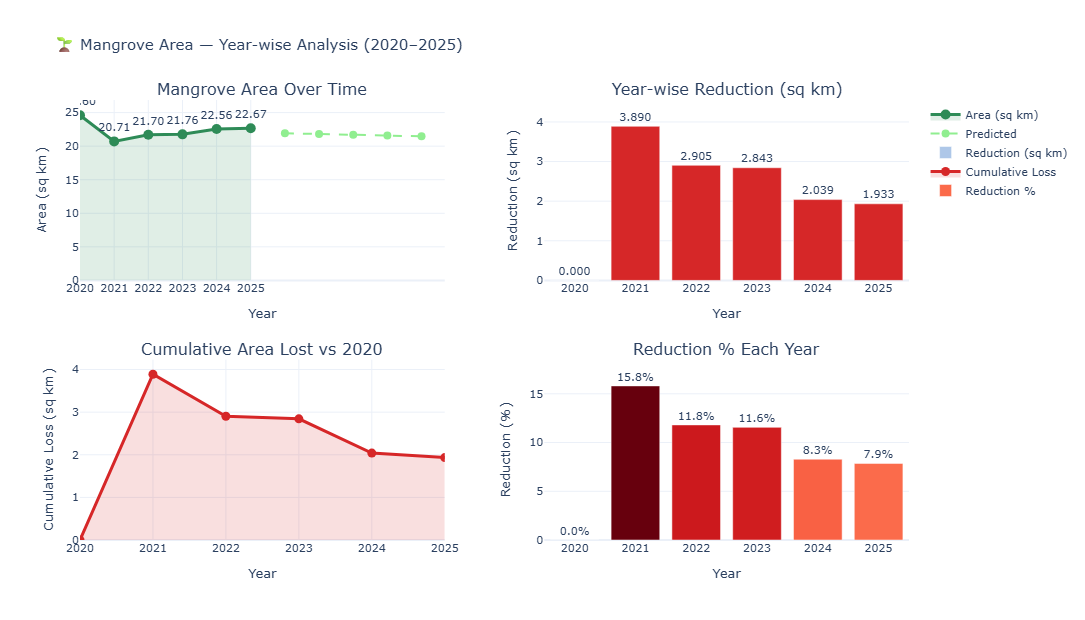

In [7]:
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Mangrove Area Over Time',
        'Year-wise Reduction (sq km)',
        'Cumulative Area Lost vs 2020',
        'Reduction % Each Year'
    ),
    vertical_spacing=0.18, horizontal_spacing=0.12
)

# Top left - area trend
fig2.add_trace(go.Scatter(
    x=df['year'], y=df['mangrove_area_sq_km'],
    mode='lines+markers+text',
    text=[f"{v:.2f}" for v in df['mangrove_area_sq_km']],
    textposition='top center',
    line=dict(color='#2E8B57', width=3), marker=dict(size=10),
    fill='tozeroy', fillcolor='rgba(46,139,87,0.15)',
    name='Area (sq km)'
), row=1, col=1)

# Prediction line
fig2.add_trace(go.Scatter(
    x=future_df['year'], y=future_df['mangrove_area_sq_km'],
    mode='lines+markers', name='Predicted',
    line=dict(color='#90EE90', width=2, dash='dash'),
    marker=dict(size=8)
), row=1, col=1)

# Top right - reduction bars
colors = ['#d62728' if v > 0 else '#aec7e8' for v in df['reduction_sq_km']]
fig2.add_trace(go.Bar(
    x=df['year'], y=df['reduction_sq_km'],
    marker_color=colors,
    text=[f"{v:.3f}" for v in df['reduction_sq_km']],
    textposition='outside',
    name='Reduction (sq km)'
), row=1, col=2)

# Bottom left - cumulative loss
fig2.add_trace(go.Scatter(
    x=df['year'], y=df['area_loss_vs_baseline'],
    mode='lines+markers', fill='tozeroy',
    fillcolor='rgba(214,39,40,0.15)',
    line=dict(color='#d62728', width=3), marker=dict(size=9),
    name='Cumulative Loss'
), row=2, col=1)

# Bottom right - reduction %
fig2.add_trace(go.Bar(
    x=df['year'], y=df['reduction_percent'],
    marker=dict(color=df['reduction_percent'], colorscale='Reds', showscale=False),
    text=[f"{v:.1f}%" for v in df['reduction_percent']],
    textposition='outside',
    name='Reduction %'
), row=2, col=2)

fig2.update_layout(
    title='🌱 Mangrove Area — Year-wise Analysis (2020–2025)',
    template='plotly_white', height=620,
    showlegend=True, font=dict(size=11)
)
fig2.update_xaxes(title_text='Year', tickvals=df['year'].tolist())
fig2.update_yaxes(title_text='Area (sq km)', row=1, col=1)
fig2.update_yaxes(title_text='Reduction (sq km)', row=1, col=2)
fig2.update_yaxes(title_text='Cumulative Loss (sq km)', row=2, col=1)
fig2.update_yaxes(title_text='Reduction (%)', row=2, col=2)

fig2.show()

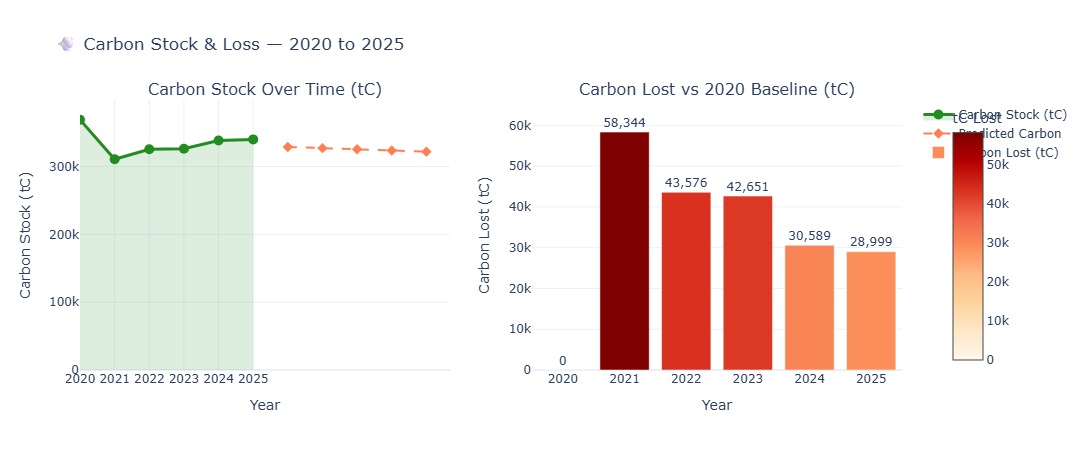

In [8]:
fig3 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Carbon Stock Over Time (tC)', 'Carbon Lost vs 2020 Baseline (tC)')
)

# Left - carbon stock
fig3.add_trace(go.Scatter(
    x=df['year'], y=df['carbon_stock_tc'],
    mode='lines+markers', fill='tozeroy',
    fillcolor='rgba(34,139,34,0.15)',
    line=dict(color='#228B22', width=3), marker=dict(size=10),
    text=[f"{v:,.0f} tC" for v in df['carbon_stock_tc']],
    hovertemplate='%{x}: %{text}<extra></extra>',
    name='Carbon Stock (tC)'
), row=1, col=1)

# Prediction
fig3.add_trace(go.Scatter(
    x=future_df['year'], y=future_df['carbon_stock_tc'],
    mode='lines+markers', name='Predicted Carbon',
    line=dict(color='#FF7F50', width=2, dash='dash'),
    marker=dict(size=8, symbol='diamond')
), row=1, col=1)

# Right - carbon loss bars
fig3.add_trace(go.Bar(
    x=df['year'], y=df['carbon_loss_tc'],
    marker=dict(color=df['carbon_loss_tc'], colorscale='OrRd', showscale=True,
                colorbar=dict(title='tC Lost', x=1.05)),
    text=[f"{v:,.0f}" for v in df['carbon_loss_tc']],
    textposition='outside',
    name='Carbon Lost (tC)'
), row=1, col=2)

fig3.update_layout(
    title='💨 Carbon Stock & Loss — 2020 to 2025',
    template='plotly_white', height=450, font=dict(size=12)
)
fig3.update_xaxes(title_text='Year', tickvals=df['year'].tolist())
fig3.update_yaxes(title_text='Carbon Stock (tC)', row=1, col=1)
fig3.update_yaxes(title_text='Carbon Lost (tC)', row=1, col=2)

fig3.show()

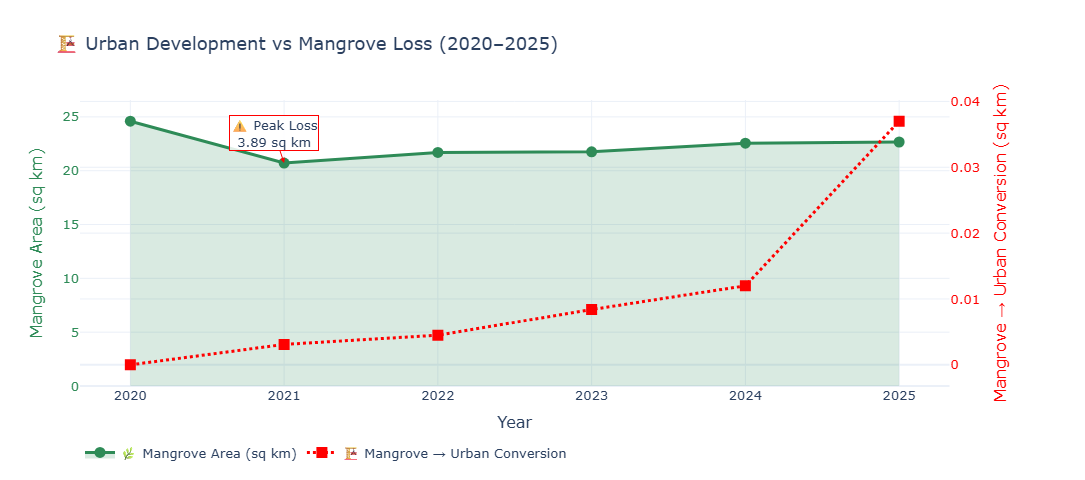

In [21]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# LOAD YOUR DATA
df = pd.read_csv(r"C:\Users\DELL\Downloads\mangrove_to_urban_2020_2025_final.csv")

fig4 = make_subplots(specs=[[{'secondary_y': True}]])

# Mangrove area
fig4.add_trace(go.Scatter(
    x=df['year'], y=df['remaining_mangrove_sq_km'],
    mode='lines+markers', fill='tozeroy',
    fillcolor='rgba(46,139,87,0.18)',
    line=dict(color='#2E8B57', width=3),
    marker=dict(size=11),
    name='🌿 Mangrove Area (sq km)'
), secondary_y=False)

# Urban impact (FIXED)
fig4.add_trace(go.Scatter(
    x=df['year'], y=df['mangrove_to_urban_sq_km'],  # FIX HERE
    mode='lines+markers',
    line=dict(color='#FF0000', width=3, dash='dot'),
    marker=dict(size=11, symbol='square'),
    name='🏗️ Mangrove → Urban Conversion'
), secondary_y=True)

# Mark worst year
worst_idx = df['mangrove_loss_sq_km'].idxmax()

fig4.add_annotation(
    x=df.loc[worst_idx, 'year'],
    y=df.loc[worst_idx, 'remaining_mangrove_sq_km'],
    text=f"⚠️ Peak Loss<br>{df.loc[worst_idx,'mangrove_loss_sq_km']:.2f} sq km",
    showarrow=True,
    arrowhead=2,
    arrowcolor='red',
    bgcolor='rgba(255,255,255,0.85)',
    bordercolor='red'
)

fig4.update_layout(
    title='🏗️ Urban Development vs Mangrove Loss (2020–2025)',
    xaxis_title='Year',
    template='plotly_white',
    legend=dict(orientation='h', y=-0.18),
    height=480,
    font=dict(size=13)
)

fig4.update_yaxes(
    title_text='Mangrove Area (sq km)',
    secondary_y=False,
    color='#2E8B57'
)

fig4.update_yaxes(
    title_text='Mangrove → Urban Conversion (sq km)',
    secondary_y=True,
    color='#FF0000'
)

fig4.show()

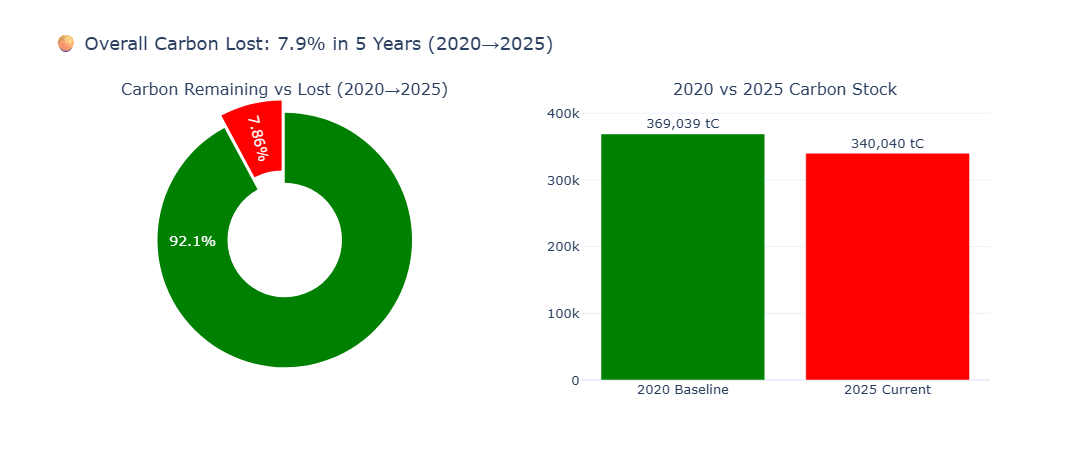


📊 Carbon 2020:  369,039 tC  =  1,354,373 tCO₂eq
📊 Carbon 2025:  340,040 tC  =  1,247,945 tCO₂eq
📉 Total Lost:   28,999 tC  =  106,428 tCO₂eq
📉 % Lost:       7.86%


In [27]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# LOAD DATA
df = pd.read_csv(r"C:\Users\DELL\Downloads\mangrove_to_urban_2020_2025_final.csv")

# CREATE CARBON COLUMN (FIX)
df["carbon_stock_tc"] = df["remaining_mangrove_sq_km"] * 100 * 150

carbon_2020 = df.loc[df['year']==2020, 'carbon_stock_tc'].values[0]
carbon_2025 = df.loc[df['year']==2025, 'carbon_stock_tc'].values[0]
loss = carbon_2020 - carbon_2025
loss_pct = (loss / carbon_2020) * 100

fig5 = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'pie'}, {'type':'xy'}]],
    subplot_titles=(
        'Carbon Remaining vs Lost (2020→2025)',
        '2020 vs 2025 Carbon Stock'
    )
)

fig5.add_trace(go.Pie(
    labels=['Remaining (2025)', 'Lost Since 2020'],
    values=[carbon_2025, loss],
    hole=0.45,
    marker_colors=['#008000','#FF0000'],
    textinfo='percent',
    textposition='inside',          # 🔥 FIX (inside kar diya)
    insidetextorientation='radial',
    pull=[0, 0.1],
    textfont=dict(size=14, color='white')
), row=1, col=1)

fig5.add_trace(go.Bar(
    x=['2020 Baseline', '2025 Current'],
    y=[carbon_2020, carbon_2025],
    marker_color=['#008000','#FF0000'],
    text=[f"{carbon_2020:,.0f} tC", f"{carbon_2025:,.0f} tC"],
    textposition='outside',
    name='Carbon Stock'
), row=1, col=2)

fig5.update_layout(
    title=f'🥧 Overall Carbon Lost: {loss_pct:.1f}% in 5 Years (2020→2025)',
    template='plotly_white', height=460, font=dict(size=13), showlegend=False
)

fig5.show()

print(f"\n📊 Carbon 2020:  {carbon_2020:,.0f} tC  =  {carbon_2020*3.67:,.0f} tCO₂eq")
print(f"📊 Carbon 2025:  {carbon_2025:,.0f} tC  =  {carbon_2025*3.67:,.0f} tCO₂eq")
print(f"📉 Total Lost:   {loss:,.0f} tC  =  {loss*3.67:,.0f} tCO₂eq")
print(f"📉 % Lost:       {loss_pct:.2f}%")

In [47]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go

# ✅ CLEAN COLUMN NAMES
df.columns = df.columns.str.strip()

# ✅ SAFE COLUMN DETECTION
area_col = [c for c in df.columns if 'mangrove' in c.lower()][0]

loss_candidates = [c for c in df.columns if 'loss' in c.lower()]
loss_col = loss_candidates[0] if loss_candidates else area_col  # fallback

urban_candidates = [c for c in df.columns if 'urban' in c.lower()]
urban_col = urban_candidates[0] if urban_candidates else area_col  # fallback

# ✅ CREATE REQUIRED COLUMNS
df["carbon_stock_tc"] = df[area_col] * 100 * 150
df["carbon_loss_tc"] = df["carbon_stock_tc"].iloc[0] - df["carbon_stock_tc"]

# DROPDOWNS
year_drop = widgets.Dropdown(
    options=['All Years'] + df['year'].tolist(),
    value='All Years',
    description='Year:',
    style={'description_width': 'initial'}
)

metric_drop = widgets.Dropdown(
    options=[
        ('Mangrove Area (sq km)', area_col),
        ('Mangrove Loss (sq km)', loss_col),
        ('Mangrove → Urban (sq km)', urban_col),
        ('Carbon Stock (tC)', 'carbon_stock_tc'),
        ('Carbon Loss (tC)', 'carbon_loss_tc')
    ],
    value=area_col,
    description='Metric:',
    style={'description_width': 'initial'}
)

out = widgets.Output()

def update(year_sel, metric):
    with out:
        clear_output(wait=True)

        if year_sel == 'All Years':
            fig = go.Figure()
            fig.add_trace(go.Scatter(
                x=df['year'], y=df[metric],
                mode='lines+markers+text',
                text=[f"{v:.2f}" for v in df[metric]],
                textposition='top center',
                line=dict(color='#008000', width=3),
                marker=dict(size=11, color=df[metric], colorscale='Greens', showscale=True),
                fill='tozeroy', fillcolor='rgba(0,128,0,0.12)'
            ))
            fig.update_layout(
                title=f'📅 {metric} — All Years',
                xaxis_title='Year', yaxis_title=metric,
                template='plotly_white', height=420
            )

        else:
            bar_colors = ['#FF0000' if y == year_sel else '#008000' for y in df['year']]
            sel_val = df.loc[df['year']==year_sel, metric].values[0]

            fig = go.Figure()
            fig.add_trace(go.Bar(
                x=df['year'], y=df[metric],
                marker_color=bar_colors,
                text=[f"{v:.2f}" for v in df[metric]],
                textposition='outside'
            ))

            fig.add_hline(
                y=sel_val,
                line_dash='dash',
                line_color='red',
                annotation_text=f"{year_sel}: {sel_val:.2f}"
            )

            fig.update_layout(
                title=f'📅 {metric} — {year_sel} Highlighted',
                xaxis_title='Year', yaxis_title=metric,
                template='plotly_white', height=420
            )

        fig.show()

w = widgets.interactive(update, year_sel=year_drop, metric=metric_drop)

display(year_drop, metric_drop, out)

update('All Years', area_col)

Dropdown(description='Year:', options=('All Years', 2020, 2021, 2022, 2023, 2024, 2025), style=DescriptionStyl…

Dropdown(description='Metric:', options=(('Mangrove Area (sq km)', 'mangrove_area_sq_km'), ('Mangrove Loss (sq…

Output(outputs=({'output_type': 'display_data', 'data': {'application/vnd.plotly.v1+json': {'data': [{'fill': …

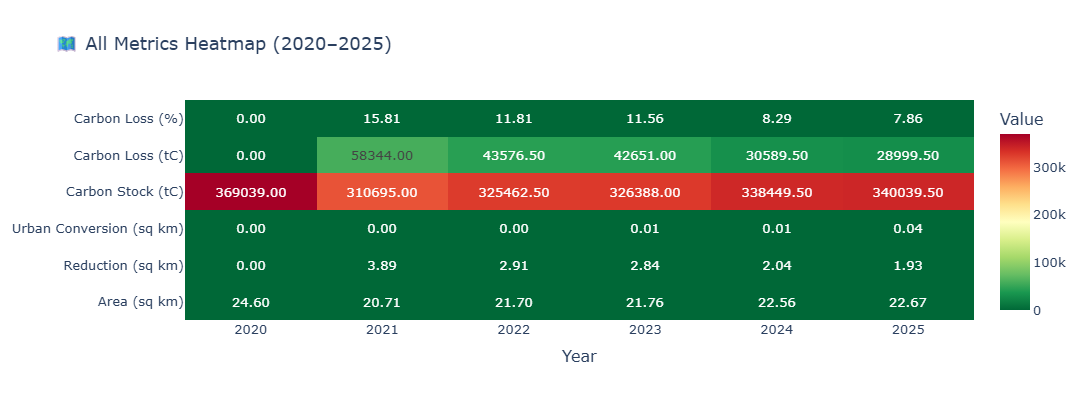

In [31]:
# ✅ CREATE REQUIRED COLUMNS
df["carbon_stock_tc"] = df["remaining_mangrove_sq_km"] * 100 * 150
df["carbon_loss_tc"] = df["carbon_stock_tc"].iloc[0] - df["carbon_stock_tc"]
df["carbon_loss_percent"] = (df["carbon_loss_tc"] / df["carbon_stock_tc"].iloc[0]) * 100

# ✅ FIXED METRICS (only column names changed)
metrics_heat = [
    'remaining_mangrove_sq_km',
    'mangrove_loss_sq_km',
    'mangrove_to_urban_sq_km',
    'carbon_stock_tc',
    'carbon_loss_tc',
    'carbon_loss_percent'
]

labels_heat  = [
    'Area (sq km)',
    'Reduction (sq km)',
    'Urban Conversion (sq km)',
    'Carbon Stock (tC)',
    'Carbon Loss (tC)',
    'Carbon Loss (%)'
]

z = df[metrics_heat].values.T

fig8 = go.Figure(go.Heatmap(
    z=z,
    x=df['year'].tolist(),
    y=labels_heat,
    colorscale='RdYlGn_r',
    text=[[f"{v:.2f}" for v in row] for row in z],
    texttemplate='%{text}',
    showscale=True,
    colorbar=dict(title='Value')
))

fig8.update_layout(
    title='🗺️ All Metrics Heatmap (2020–2025)',
    xaxis_title='Year', template='plotly_white',
    height=400, font=dict(size=13)
)

fig8.show()

In [32]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

df = pd.read_csv('mangrove_engineered.csv')
print('✅ Data loaded')
display(df)

✅ Data loaded


,year,mangrove_area_sq_km,reduction_sq_km,reduction_percent,area_ha,carbon_stock_tc,carbon_loss_tc,carbon_loss_percent,urban_index,area_loss_vs_baseline,carbon_stock_co2eq,carbon_loss_co2eq
0,2020,24.6026,0.0000,0.0000,2460.26,369039.0,0.0,0.000000,0.00,0.0000,1354373.130,0.000
1,2021,20.7130,3.8896,15.8096,2071.30,310695.0,58344.0,15.809711,15.81,3.8896,1140250.650,214122.480
2,2022,21.6975,2.9051,11.8082,2169.75,325462.5,43576.5,11.808102,11.81,2.9051,1194447.375,159925.755
3,2023,21.7592,2.8434,11.5573,2175.92,326388.0,42651.0,11.557315,11.56,2.8434,1197843.960,156529.170
4,2024,22.5633,2.0393,8.2889,2256.33,338449.5,30589.5,8.288961,8.29,2.0393,1242109.665,112263.465
5,2025,22.6693,1.9333,7.8581,2266.93,340039.5,28999.5,7.858113,7.86,1.9333,1247944.965,106428.165


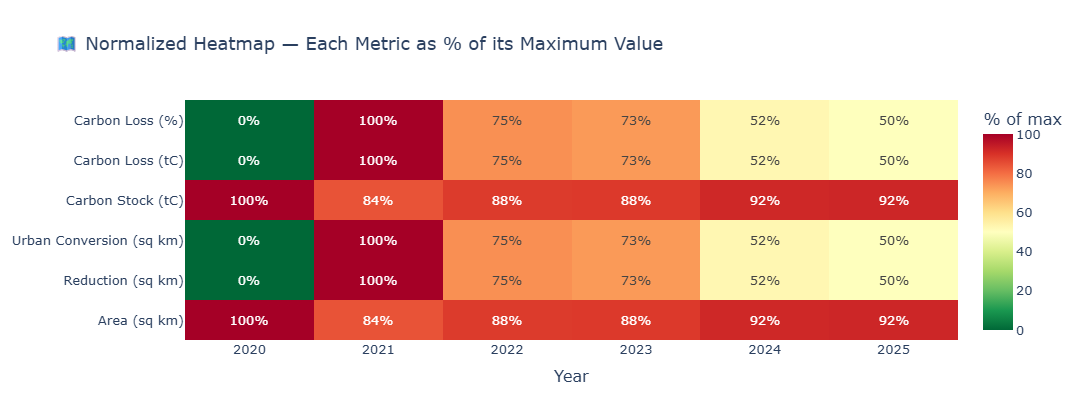

In [38]:
import numpy as np  # ✅ REQUIRED

# z should already be defined from previous code:
# z = df[metrics].values.T

z_norm = np.zeros_like(z, dtype=float)

for i, row in enumerate(z):
    rmax = row.max()
    z_norm[i] = row / rmax * 100 if rmax != 0 else row

fig2 = go.Figure(go.Heatmap(
    z=z_norm,
    x=df['year'].tolist(),
    y=labels,
    colorscale='RdYlGn_r',
    text=[[f'{v:.0f}%' for v in row] for row in z_norm],
    texttemplate='%{text}',
    showscale=True,
    colorbar=dict(title='% of max')
))

fig2.update_layout(
    title='🗺️ Normalized Heatmap — Each Metric as % of its Maximum Value',
    xaxis_title='Year',
    template='plotly_white',
    height=420,
    font=dict(size=13)
)

fig2.show()

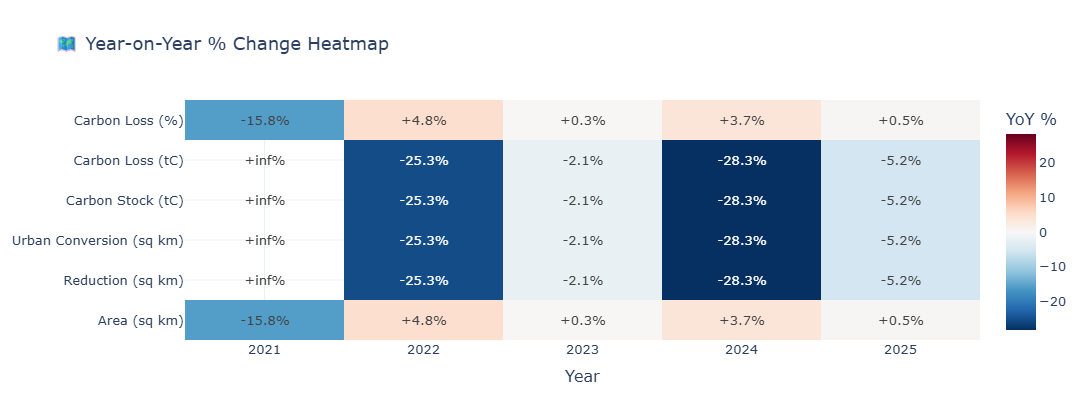

In [40]:

df.columns = df.columns.str.strip()

# ✅ CREATE REQUIRED COLUMNS (if not already created)
df["carbon_stock_tc"] = df[df.columns[df.columns.str.contains("mangrove", case=False)][0]] * 100 * 150
df["carbon_loss_tc"] = df["carbon_stock_tc"].iloc[0] - df["carbon_stock_tc"]
df["carbon_loss_percent"] = (df["carbon_loss_tc"] / df["carbon_stock_tc"].iloc[0]) * 100

# ✅ DEFINE METRICS (safe mapping)
metrics = [col for col in df.columns if any(k in col.lower() for k in ['mangrove', 'loss', 'urban'])]
metrics = metrics[:3] + ['carbon_stock_tc', 'carbon_loss_tc', 'carbon_loss_percent']

labels = ['Area (sq km)', 'Reduction (sq km)', 'Urban Conversion (sq km)',
          'Carbon Stock (tC)', 'Carbon Loss (tC)', 'Carbon Loss (%)']

# ================= YOUR ORIGINAL CODE =================

pct = df[metrics].pct_change() * 100
pct['year'] = df['year']
pct = pct.dropna().reset_index(drop=True)

z_pct = pct[metrics].values.T

fig3 = go.Figure(go.Heatmap(
    z=z_pct,
    x=pct['year'].tolist(),
    y=labels,
    colorscale='RdBu_r',
    zmid=0,
    text=[[f'{v:+.1f}%' for v in row] for row in z_pct],
    texttemplate='%{text}',
    showscale=True,
    colorbar=dict(title='YoY %')
))

fig3.update_layout(
    title='🗺️ Year-on-Year % Change Heatmap',
    xaxis_title='Year',
    template='plotly_white',
    height=420,
    font=dict(size=13)
)

fig3.show()